In [247]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats
import matplotlib.ticker as mtick
from sqlalchemy import create_engine, types

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

In [220]:
# Step 1: Load the files
risk_df = pd.read_csv('..\data\hypertension_risk_factor_ratios.csv')
all_inner_merge_df = pd.read_csv('../data/analysis_data/dietary_demo_exam_quest_merged.csv')

In [221]:

# Step 3: Keep only the desired columns
columns_to_keep = ['Participant_ID', 'energy_intake', 'cholesterol_score',
                   'fat_quality_score','avg_sleep_hrs', 'Hypertensive']
merged_df = all_inner_merge_df [columns_to_keep]

In [222]:
merged_df

,Participant_ID,energy_intake,cholesterol_score,fat_quality_score,avg_sleep_hrs,Hypertensive
0,130378,1740.0,274.0,0.54,9.25,True
1,130379,2741.0,131.0,1.76,9.00,True
2,130380,1995.0,270.0,0.43,8.50,False
3,130386,2422.0,489.0,0.84,7.75,False
4,130387,3849.0,279.0,2.09,4.00,True
...,...,...,...,...,...,...
4981,142302,1267.0,61.0,0.50,9.00,True
4982,142303,280.0,7.0,0.93,9.00,False
4983,142307,1609.0,142.0,1.35,7.00,True
4984,142309,4651.0,402.0,0.45,10.00,True


In [223]:
# STEP 1: Load your merged dataset
df = merged_df.copy()  # Assuming you already merged nutrient + demographic data

# STEP 2: Ensure 'Hypertensive' is numeric (convert from bool)
df['Hypertensive'] = df['Hypertensive'].astype(int)
# Ensuring 'activity_level' is numeric (convert from string)
#df['activity_level'] = df['activity_level'].map({'Active': 1, 'Not Active': 0})

# STEP 3: Select only numeric columns
numeric_df = df.select_dtypes(include='number')

# STEP 4: Drop ID column if it's not analytically useful
numeric_df = numeric_df.drop(columns=['Participant_ID'], errors='ignore')

# STEP 5: Compute correlation matrix
corr_matrix = numeric_df.corr()

# STEP 6: Focus on correlations with 'Hypertensive' only
hypertension_corr = corr_matrix[['Hypertensive']].sort_values(by='Hypertensive', ascending=False)



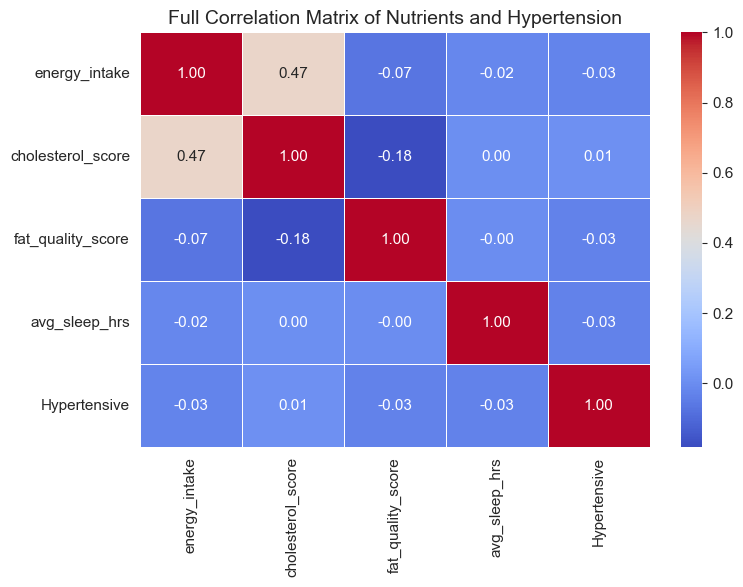

In [224]:
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Full Correlation Matrix of Nutrients and Hypertension")
plt.tight_layout()
plt.show()

In [225]:

# Step 3: Keep only the desired columns
columns_to_keep = ['Participant_ID','BMI','energy_intake','activity_level','Abdominal_Obesity',
                   'sed_minutes', 'Hypertensive']
df = all_inner_merge_df [columns_to_keep]
df['Abdominal_Obesity'] = df['Abdominal_Obesity'].astype(bool)

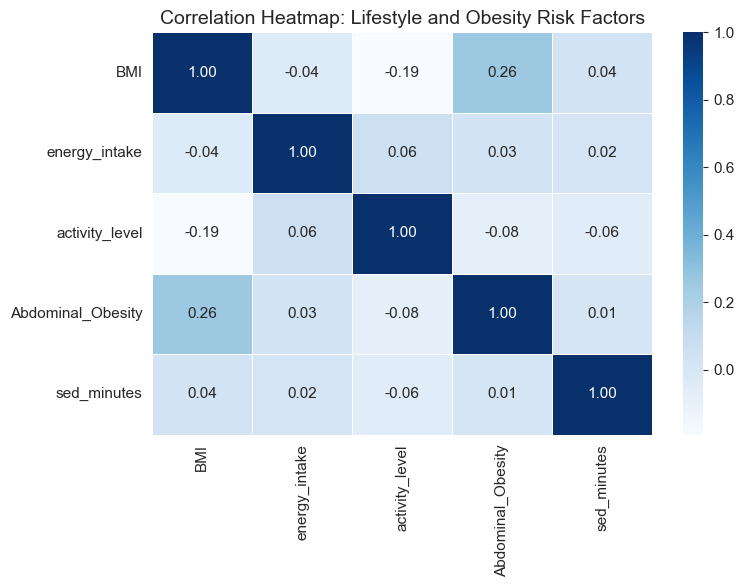

In [226]:
# Step 1: Map categorical strings to numeric values
df['activity_level'] = df['activity_level'].map({'Active': 1, 'Not Active': 0})

# Step 2: Map Abdominal_Obesity (if not already numeric)
df['Hypertensive'] = df['Hypertensive'].astype(int)
df['Abdominal_Obesity'] = df['Abdominal_Obesity'].astype(int)
  

# Step 3: Select relevant variables
selected_vars = df[['BMI', 'energy_intake', 'activity_level', 'Abdominal_Obesity', 'sed_minutes']]

# Step 4: Compute correlation matrix
corr_matrix = selected_vars.corr()

# Step 5: Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Lifestyle and Obesity Risk Factors")
plt.tight_layout()
plt.show()

In [227]:
import statsmodels.api as sm
from scipy.stats import pearsonr

def partial_corr(x, y, controls, data):
    # Regress x on controls
    x_model = sm.OLS(data[x], sm.add_constant(data[controls])).fit()
    x_resid = x_model.resid

    # Regress y on controls
    y_model = sm.OLS(data[y], sm.add_constant(data[controls])).fit()
    y_resid = y_model.resid

    # Correlate the residuals
    corr, pval = pearsonr(x_resid, y_resid)
    return corr, pval

Composite Nutrient Quality Score

In [228]:
dietary_df = pd.read_csv('../data/dietary_data/dietary_nutrient_avg_data.csv')
demographic_df = pd.read_csv('../data/analysis_data/dietary_demo_exam_quest_merged.csv')

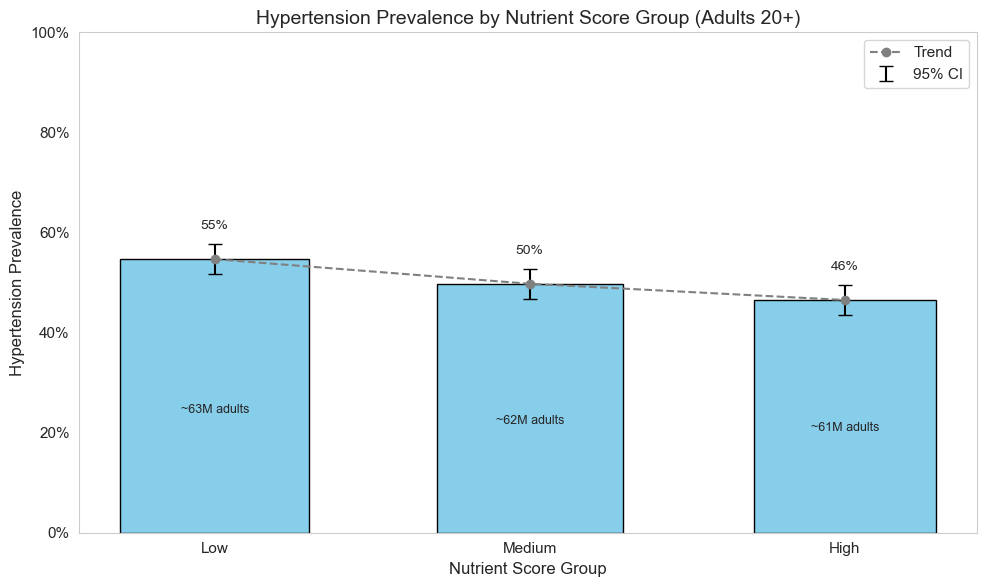

In [259]:
demographic_df = demographic_df.rename(columns={'Participant_ID':'seqn_no'})
df_merged = pd.merge(dietary_df, demographic_df, on='seqn_no', how='inner')


# --- Filter: Adults 20+, valid data ---
df_ns = df_merged[
    (df_merged['Age'] >= 20) &
    df_merged['nutrient_score'].notna() &
    df_merged['Hypertensive'].notna() &
    (df_merged['Exam_Weight'] > 0)
].copy()

# --- Create nutrient score tertiles (or change to quartiles if preferred) ---
df_ns['nutrient_score_group'] = pd.qcut(df_ns['nutrient_score'], q=3, labels=['Low', 'Medium', 'High'])

# --- Function to compute weighted prevalence with CI ---
def compute_weighted_ci(group):
    weights = group['Exam_Weight']
    p = np.average(group['Hypertensive'], weights=weights)
    w_sum = weights.sum()
    n_eff = w_sum**2 / (weights**2).sum()
    se = np.sqrt(p * (1 - p) / n_eff)
    return pd.Series({
        'Weighted_Hypertension_Prevalence': p,
        'CI_Lower': max(0, p - 1.96 * se),
        'CI_Upper': min(1, p + 1.96 * se),
        'Weighted_Population': w_sum
    })

# --- Apply group analysis ---
ns_results = (
    df_ns
    .groupby('nutrient_score_group')
    .apply(compute_weighted_ci)
    .reset_index()
)

# --- Normalize population for bar widths ---
ns_results['Norm_Pop'] = ns_results['Weighted_Population'] / ns_results['Weighted_Population'].max()

# --- Plot ---
plt.figure(figsize=(10, 6))
bar_positions = np.arange(len(ns_results))

bars = plt.bar(
    bar_positions,
    ns_results['Weighted_Hypertension_Prevalence'],
    width=ns_results['Norm_Pop'] * 0.6,
    color="skyblue",
    edgecolor='black'
)

# --- Error bars ---
plt.errorbar(
    x=bar_positions,
    y=ns_results['Weighted_Hypertension_Prevalence'],
    yerr=[
        ns_results['Weighted_Hypertension_Prevalence'] - ns_results['CI_Lower'],
        ns_results['CI_Upper'] - ns_results['Weighted_Hypertension_Prevalence']
    ],
    fmt='none', ecolor='black', capsize=5, label="95% CI"
)

# --- Labels ---
for i, row in ns_results.iterrows():
    percent = int(round(row['Weighted_Hypertension_Prevalence'] * 100))
    pop_m = int(round(row['Weighted_Population'] / 1_000_000))

    plt.text(i, row['Weighted_Hypertension_Prevalence'] * 0.45,
             f"~{pop_m}M adults", ha='center', va='center', fontsize=9)

    plt.text(i, row['CI_Upper'] + 0.03,
             f"{percent}%", ha='center', fontsize=10)

# --- Trend line ---
plt.plot(bar_positions, ns_results['Weighted_Hypertension_Prevalence'],
         marker='o', linestyle='--', color='gray', label='Trend')

# --- Aesthetics ---
plt.xticks(bar_positions, ns_results['nutrient_score_group'])
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.title("Hypertension Prevalence by Nutrient Score Group (Adults 20+)")
plt.xlabel("Nutrient Score Group")
plt.ylabel("Hypertension Prevalence")
plt.ylim(0, 1)
plt.grid(False)
plt.legend()
plt.tight_layout()
plt.show()

In [229]:
from sklearn.preprocessing import MinMaxScaler

# Step 1: Select relevant nutrient columns
positive_nutrients = [
    'dietary_fiber_gms', 'protein_gms', 'poly_unsaturated_fats_gms',
    'mono_saturated_fats_gms', 'potassium_mg', 'vitaminD_mcg',
    'vitaminC_mg', 'vitaK_mcg', 'calcium_mg'
]

negative_nutrients = [
    'saturated_fats_gms', 'cholestrol_gms', 'sodium_mg', 'total_sugars_gms'
]

all_nutrients = positive_nutrients + negative_nutrients

# Step 2: Drop rows with missing values for selected nutrients

imputer = KNNImputer(n_neighbors=5)
df_nutrient[all_nutrients] = imputer.fit_transform(df_nutrient[all_nutrients])
df_nutrient = dietary_df[all_nutrients].fillna(0).copy()

# Step 3: Normalize using MinMaxScaler
scaler = MinMaxScaler()
normalized = pd.DataFrame(scaler.fit_transform(df_nutrient), columns=all_nutrients)

# Step 4: Invert the negative nutrient scores for unhealthy nutrients
for col in negative_nutrients:
    normalized[col] = 1 - normalized[col]

# Step 5: Calculate the composite nutrient score
dietary_df['nutrient_score'] = normalized.mean(axis=1)



In [230]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler


# Step 1: Select relevant nutrient columns
positive_nutrients = [
    'dietary_fiber_gms', 'protein_gms', 'poly_unsaturated_fats_gms',
    'mono_saturated_fats_gms', 'potassium_mg', 'vitaminD_mcg',
    'vitaminC_mg', 'vitaK_mcg', 'calcium_mg'
]

negative_nutrients = [
    'saturated_fats_gms', 'cholestrol_gms', 'sodium_mg', 'total_sugars_gms'
]

all_nutrients = positive_nutrients + negative_nutrients

# Step 2: Create copy and apply KNN imputation (this avoids artificial skew)
df_nutrient = dietary_df[all_nutrients].copy()  # ← do this BEFORE imputation
imputer = KNNImputer(n_neighbors=5)
df_nutrient[all_nutrients] = imputer.fit_transform(df_nutrient)

# Step 3: Normalize using MinMaxScaler
scaler = MinMaxScaler()
normalized = pd.DataFrame(
    scaler.fit_transform(df_nutrient),
    columns=all_nutrients
)

# Step 4: Invert the negative nutrient scores
for col in negative_nutrients:
    normalized[col] = 1 - normalized[col]

# Step 5: Calculate composite nutrient score and assign to original dataframe
dietary_df['nutrient_score'] = normalized.mean(axis=1)

In [268]:
dietary_df['nutrient_score'].describe()

count    6694.000000
mean        0.346104
std         0.025323
min         0.270928
25%         0.329593
50%         0.341525
75%         0.357174
max         0.526283
Name: nutrient_score, dtype: float64

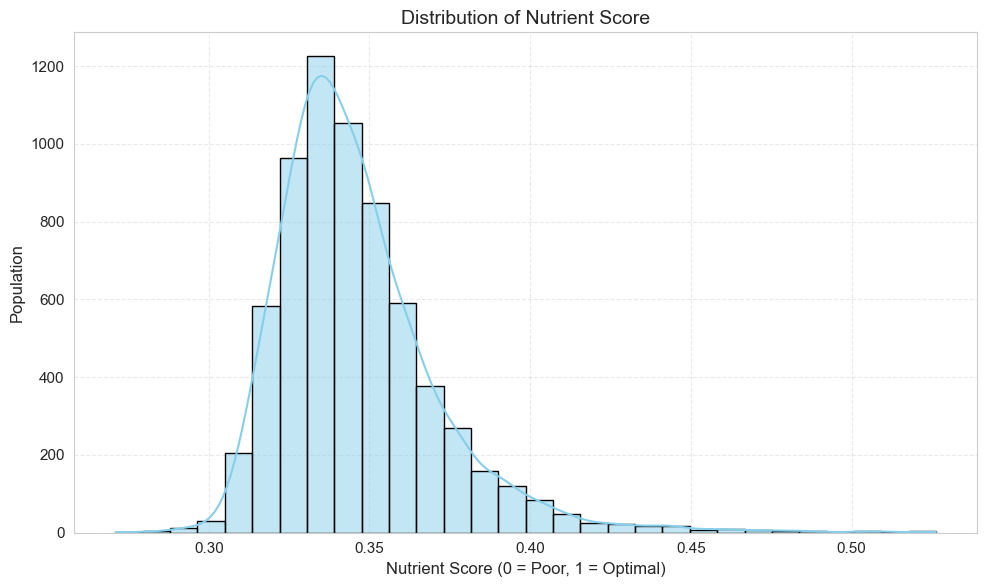

In [263]:

plt.figure(figsize=(10, 6))
sns.histplot(dietary_df['nutrient_score'], bins=30, kde=True,color='skyblue',edgecolor= 'black')
plt.title("Distribution of Nutrient Score", fontsize=14)
plt.xlabel("Nutrient Score (0 = Poor, 1 = Optimal)")
plt.ylabel("Population")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [264]:
# Basic summary stats
print(dietary_df['nutrient_score'].describe())

count    6694.000000
mean        0.346104
std         0.025323
min         0.270928
25%         0.329593
50%         0.341525
75%         0.357174
max         0.526283
Name: nutrient_score, dtype: float64


In [265]:
# Merge with demographic info containing 'Hypertensive'
demographic_df = demographic_df.rename(columns={'Participant_ID':'seqn_no'})
analysis_df = pd.merge(dietary_df, demographic_df, on='seqn_no', how='inner')

In [ ]:
analysis_df

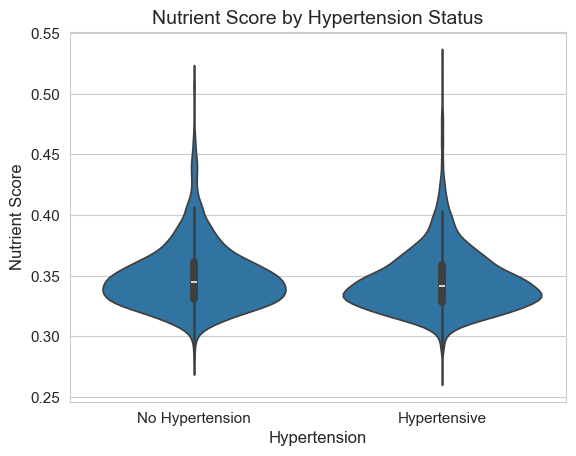

In [266]:
sns.violinplot(data=analysis_df, x='Hypertensive', y='nutrient_score')
plt.title("Nutrient Score by Hypertension Status")
plt.xticks([0, 1], ['No Hypertension', 'Hypertensive'])
plt.xlabel("Hypertension")
plt.ylabel("Nutrient Score")
plt.show()

Specifying the features to perform the Logit regression 

In [267]:
# Fill missing BMI with mean (or use median)
analysis_df['BMI'] = analysis_df['BMI'].fillna(analysis_df['BMI'].mean())

# Apply the map to the 'activity_level' column of your DataFrame
# Strip spaces and make lowercase
analysis_df['activity_level'] = analysis_df['activity_level'].str.strip().str.lower()
# Map to binary
analysis_df['activity_level'] = analysis_df['activity_level'].map({'active': 1, 'not active': 0})
# Map to binary
analysis_df['Gender'] = analysis_df['Gender'].map({'male': 1, 'female': 2})

analysis_df['Hypertensive'] = analysis_df['Hypertensive'].astype(int)

# Now, your 'features' list just holds the column names, which represents the predictive scores
features = ['nutrient_score', 'Age', 'BMI','Gender', 'activity_level','Race_Ethnicity']


X = analysis_df[features]
X = sm.add_constant(X)  # Adds intercept
y = analysis_df['Hypertensive']
print(X,y)
model = sm.Logit(y, X).fit()
print(model.summary())

      const  nutrient_score  Age        BMI  Gender  activity_level  \
0       1.0        0.332866   43  27.000000       1               1   
1       1.0        0.375464   66  33.500000       1               1   
2       1.0        0.354349   44  29.700000       2               0   
3       1.0        0.361200   34  30.200000       1               0   
4       1.0        0.403404   68  42.600000       2               0   
...     ...             ...  ...        ...     ...             ...   
4981    1.0        0.314165   70  21.400000       1               1   
4982    1.0        0.322839   69  27.900000       2               1   
4983    1.0        0.373527   49  29.818666       2               0   
4984    1.0        0.370521   40  25.500000       1               1   
4985    1.0        0.328477   80  27.600000       2               0   

      Race_Ethnicity  
0                  6  
1                  3  
2                  2  
3                  1  
4                  3  
...      

Logit Regression

In [237]:
# Force all columns to numeric (especially for categorical encoding)
X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

# Combine X and y to clean missing rows at once
full_df = pd.concat([X, y], axis=1).dropna()

# Redefine X and y after dropping rows
X = full_df.drop(columns='Hypertensive')
y = full_df['Hypertensive']


# Logistic Regression
X = sm.add_constant(X)
logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.566669
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           Hypertensive   No. Observations:                 4986
Model:                          Logit   Df Residuals:                     4979
Method:                           MLE   Df Model:                            6
Date:                Wed, 18 Jun 2025   Pseudo R-squ.:                  0.1774
Time:                        19:49:57   Log-Likelihood:                -2825.4
converged:                       True   LL-Null:                       -3434.6
Covariance Type:            nonrobust   LLR p-value:                5.051e-260
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -2.1980      0.505     -4.353      0.000      -3.188      -1.208
nutrient_score   

In [238]:
# Step 1: Get predicted probabilities
df_predict = pd.DataFrame(model.predict(X))

In [239]:
model.predict(X)

0       0.480029
1       0.762951
2       0.356941
3       0.333500
4       0.805389
          ...   
4981    0.701246
4982    0.730766
4983    0.429315
4984    0.300802
4985    0.802001
Length: 4986, dtype: float64

In [240]:
import numpy as np

# Extract and exponentiate coefficients
coef_series = model.params  # model is the result from Logit().fit()

# Calculate % change in odds
odds_change_pct = (np.exp(coef_series) - 1) * 100

# Create a nice DataFrame for display
odds_df = pd.DataFrame({
    'Feature': coef_series.index,
    'Coefficient': coef_series.values,
    '% Change in Odds': odds_change_pct.round(2)
})

print(odds_df)

                       Feature  Coefficient  % Change in Odds
const                    const    -2.198024            -88.90
nutrient_score  nutrient_score    -5.752820            -99.68
Age                        Age     0.053400              5.49
BMI                        BMI     0.072887              7.56
Gender                  Gender    -0.502589            -39.50
activity_level  activity_level    -0.144641            -13.47
Race_Ethnicity  Race_Ethnicity     0.069350              7.18


# Density plot for probability of Hypertension 

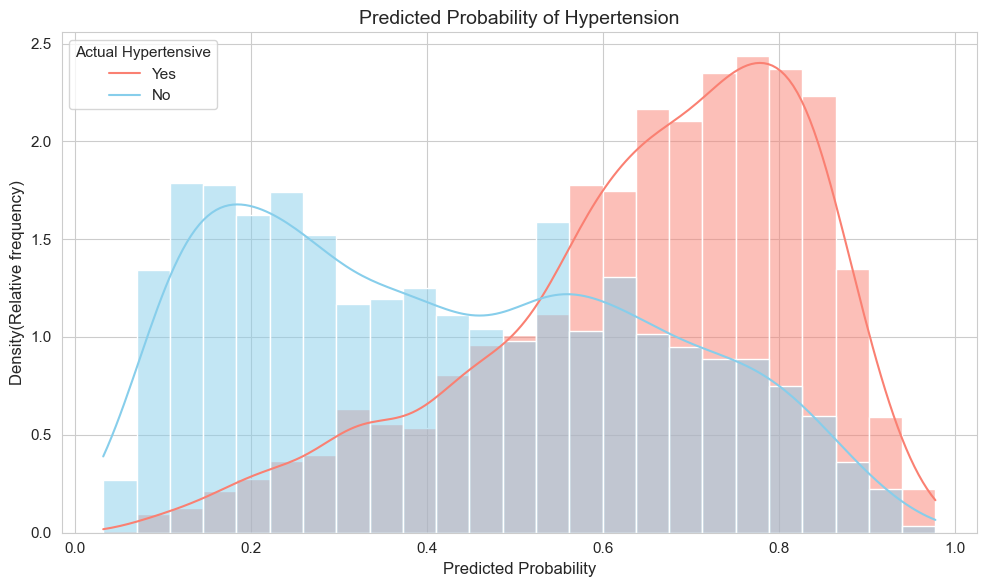

In [241]:
# Step 1: Get predicted probabilities
analysis_df['predicted_prob'] = model.predict(X)

# Step 2: Plot histogram of predicted probabilities grouped by actual hypertension status
plt.figure(figsize=(10, 6))
sns.histplot(
    data=analysis_df,
    x='predicted_prob',
    hue='Hypertensive',
    bins=25,
    kde=True,
    stat='density',
    common_norm=False,
    palette={0: 'skyblue', 1: 'salmon'}
)

plt.title('Predicted Probability of Hypertension')
plt.xlabel('Predicted Probability')
plt.ylabel('Density(Relative frequency)')
plt.legend(title='Actual Hypertensive', labels=['Yes', 'No'])
plt.tight_layout()
plt.show()

# The density plot with coefficient percentages

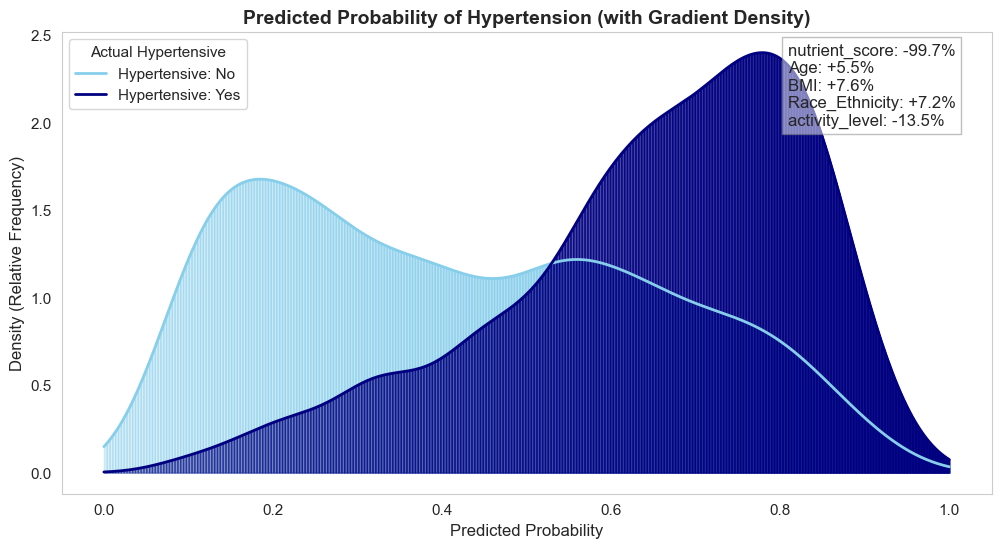

In [242]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
import numpy as np

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 14, 'axes.labelsize': 12})

# Prepare figure
fig, ax = plt.subplots(figsize=(12, 6))

# Colors for gradient
colors = {0: 'skyblue', 1: 'navy'}
labels = {0: 'No', 1: 'Yes'}

# KDE with gradient fill
for hypertensive_status in [0, 1]:
    subset = analysis_df[analysis_df['Hypertensive'] == hypertensive_status]['predicted_prob'].dropna()
    kde = gaussian_kde(subset)
    x_vals = np.linspace(0, 1, 300)
    y_vals = kde(x_vals)

    # Gradient fill
    for i in range(1, len(x_vals)):
        ax.fill_between(
            x_vals[i - 1:i + 1],
            y_vals[i - 1:i + 1],
            color=colors[hypertensive_status],
            alpha=0.3 + 0.7 * (i / len(x_vals))  # Gradient effect
        )

    ax.plot(x_vals, y_vals, label=f'Hypertensive: {labels[hypertensive_status]}', color=colors[hypertensive_status], linewidth=2)

# Axes and labels
ax.set_title('Predicted Probability of Hypertension (with Gradient Density)', weight='bold')
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Density (Relative Frequency)')
ax.legend(title='Actual Hypertensive')
ax.grid(False)

# Odds change annotation
annotation_text = ""
annot_features = ['nutrient_score', 'Age', 'BMI', 'Race_Ethnicity', 'activity_level']
for feature in annot_features:
    if feature in odds_df.index:
        pct = odds_df.loc[feature, '% Change in Odds']
        sign = '+' if pct >= 0 else ''
        annotation_text += f"{feature}: {sign}{pct:.1f}%\n"

plt.figtext(
    0.73, 0.79, annotation_text.strip(),
    fontsize=12,
    ha='left', va='center',
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.5)
)

plt.tight_layout(rect=[0, 1, 0.75, 1])
plt.show()

*The predicted probabilities visualized are entirely based on the features provided in the list:*

**features = ['nutrient_score', 'Age', 'BMI', 'activity_level','Race_Ethinicity']**

The X-axis represents the predicted probability of being hypertensive (from 0 to 1).
The Y-axis shows the density (relative frequency).


Two KDE-smoothed histograms (density curves) are plotted:
Red: People who are actually hypertensive (Hypertensive = 1)
Blue: People who are not hypertensive (Hypertensive = 0)

Non-hypertensive individuals cluster toward lower predicted probabilities (left side).
Hypertensive individuals tend to have higher predicted probabilities (right side).

This suggests your model is learning useful patterns: it's more likely to assign higher hypertension probabilities to actual hypertensive individuals.

In [243]:
analysis_df

,seqn_no,energy_kcal,protein_gms,carbohydrate_gms,total_sugars_gms,dietary_fiber_gms,total_fats_gms,saturated_fats_gms,mono_saturated_fats_gms,poly_unsaturated_fats_gms,...,fat_quality_score,cholesterol_score,energy_intake,vitaminD_IU,avg_sleep_hrs,sed_minutes,moderate_activity_minutes_per_week,vigorous_activity_minutes_per_week,activity_level,predicted_prob
0,130378,1740.0,80.46,169.66,43.71,10.1,55.07,21.000,17.040,11.401,...,0.54,274.0,1740.0,8.0,9.25,360.0,135.0,135.0,1,0.480029
1,130379,2741.0,86.45,314.86,113.58,29.6,67.18,14.544,19.386,25.622,...,1.76,131.0,2741.0,16.0,9.00,480.0,180.0,135.0,1,0.762951
2,130380,1995.0,69.86,281.67,114.66,21.1,65.38,26.936,18.638,11.687,...,0.43,270.0,1995.0,216.0,8.50,240.0,20.0,0.0,0,0.356941
3,130386,2422.0,132.41,207.53,37.89,25.1,116.54,33.935,46.022,28.569,...,0.84,489.0,2422.0,64.0,7.75,180.0,30.0,7.5,0,0.333500
4,130387,3849.0,68.93,376.54,227.99,22.0,234.39,49.849,63.889,104.428,...,2.09,279.0,3849.0,48.0,4.00,1200.0,0.0,0.0,0,0.805389
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4981,142302,1267.0,27.97,219.74,129.70,5.7,31.80,10.951,11.298,5.527,...,0.50,61.0,1267.0,24.0,9.00,120.0,315.0,140.0,1,0.701246
4982,142303,280.0,7.79,39.52,15.15,4.2,10.15,2.969,3.087,2.754,...,0.93,7.0,280.0,72.0,9.00,360.0,840.0,0.0,1,0.730766
4983,142307,1609.0,71.49,194.91,90.41,16.7,61.66,13.885,25.144,18.735,...,1.35,142.0,1609.0,320.0,7.00,480.0,45.0,0.0,0,0.429315
4984,142309,4651.0,206.87,531.11,102.17,36.0,189.47,80.654,54.177,35.914,...,0.45,402.0,4651.0,40.0,10.00,240.0,210.0,0.0,1,0.300802
